# Loan Default Prediction

## Problem Statement
Lending institutions face significant financial risk when borrowers default on loans. Accurately predicting the likelihood of default allows banks and financial companies to make smarter lending decisions, reduce credit risk exposure, and maintain portfolio health.

In this project, I build a classification model to predict whether a loan applicant is likely to default, using applicant demographic and financial features. I compare Logistic Regression and Random Forest classifiers and evaluate their performance using metrics appropriate for imbalanced classification problems.

**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn
**Dataset:** Loan Prediction Dataset via Kaggle
**Author:** Mihrimah Qozat

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load dataset
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (614, 13)

Column Names:
 ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Data types and missing values
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Variable Distribution:")
print(df['Loan_Status'].value_counts())
print(f"\nDefault Rate: {(df['Loan_Status'] == 'N').mean()*100:.2f}%")

Data Types:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Target Variable Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Default Rate: 31.27%


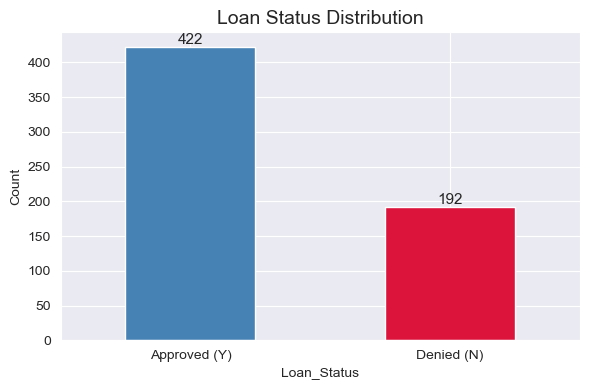

In [4]:
# Visualization for Loan Status Distribution
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['steelblue', 'crimson']
df['Loan_Status'].value_counts().plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.set_title('Loan Status Distribution', fontsize=14)
ax.set_xticklabels(['Approved (Y)', 'Denied (N)'], rotation=0)
ax.set_ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('loan_status_distribution.png', dpi=150)
plt.show()

The dataset is moderately imbalanced — the majority of applications were approved. This means we need to be careful about using accuracy as our primary metric, as a model that approves every application would still score highly on accuracy alone.

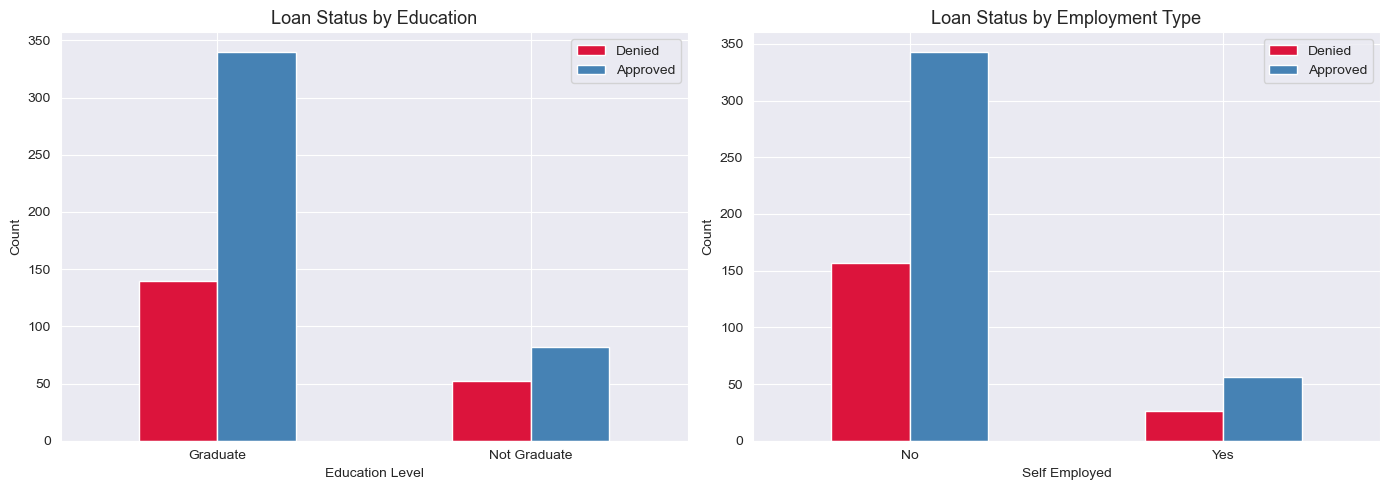

In [5]:
# Visualization for Loan Approval based on Education and Employment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Education
edu_counts = df.groupby(['Education', 'Loan_Status']).size().unstack()
edu_counts.plot(kind='bar', ax=axes[0], color=['crimson', 'steelblue'], edgecolor='white')
axes[0].set_title('Loan Status by Education', fontsize=13)
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Denied', 'Approved'])

# By Self Employment
self_emp = df.groupby(['Self_Employed', 'Loan_Status']).size().unstack()
self_emp.plot(kind='bar', ax=axes[1], color=['crimson', 'steelblue'], edgecolor='white')
axes[1].set_title('Loan Status by Employment Type', fontsize=13)
axes[1].set_xlabel('Self Employed')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Denied', 'Approved'])

plt.tight_layout()
plt.savefig('approval_by_education_employment.png', dpi=150)
plt.show()

Graduates show a higher loan approval rate than non-graduates. Self-employed applicants appear to face slightly more scrutiny, likely due to less predictable income streams — a pattern consistent with real-world lending practices.

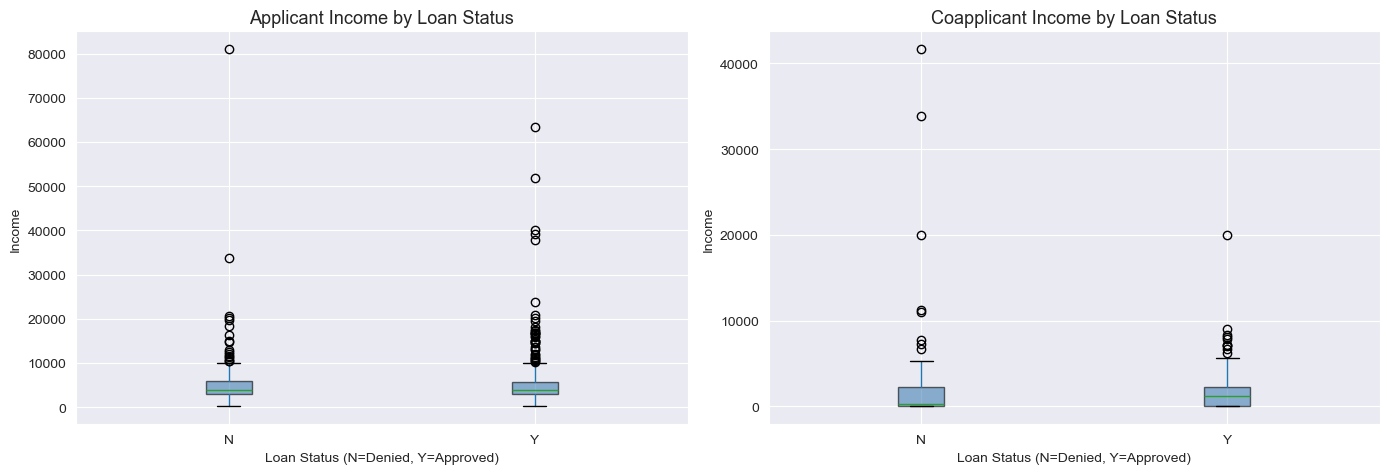

Median Applicant Income:
Loan_Status
N    3833.5
Y    3812.5
Name: ApplicantIncome, dtype: float64


In [6]:
# Visualization for Income Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['ApplicantIncome', 'CoapplicantIncome'],
                           ['Applicant Income', 'Coapplicant Income']):
    df.boxplot(column=col, by='Loan_Status', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'{title} by Loan Status', fontsize=13)
    ax.set_xlabel('Loan Status (N=Denied, Y=Approved)')
    ax.set_ylabel('Income')

plt.suptitle('')
plt.tight_layout()
plt.savefig('income_by_loan_status.png', dpi=150)
plt.show()

print("Median Applicant Income:")
print(df.groupby('Loan_Status')['ApplicantIncome'].median())

Income distributions show significant overlap between approved and denied applicants, with notable outliers. This suggests income alone is not a strong predictor of approval — the model will need to consider multiple features simultaneously to make accurate predictions.

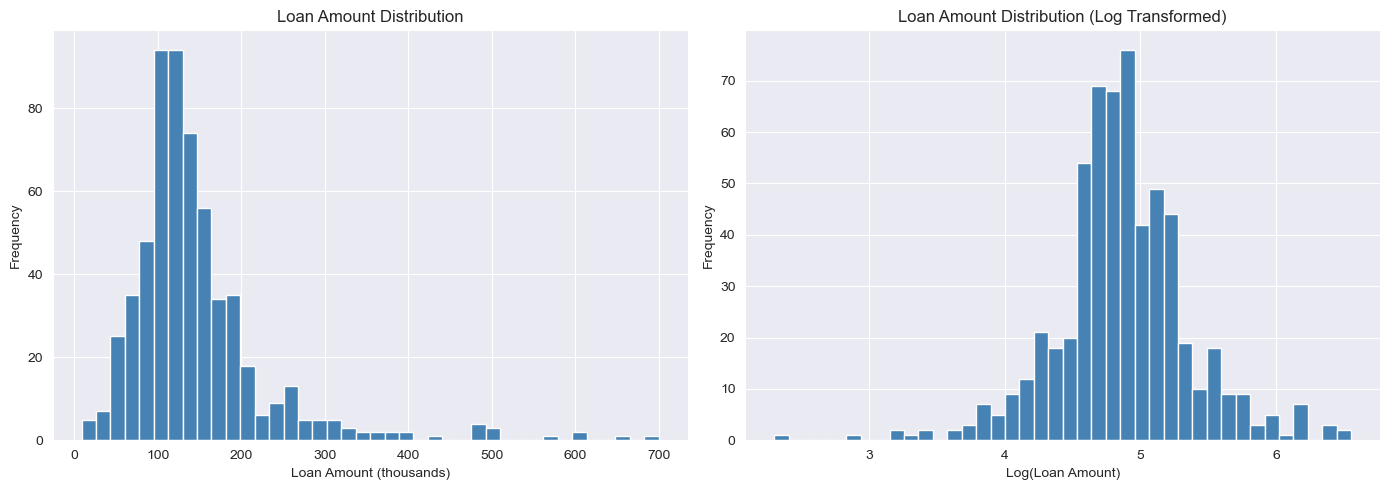

In [7]:
# Visualization for Loan Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['LoanAmount'].plot(kind='hist', bins=40, ax=axes[0],
                      color='steelblue', edgecolor='white',
                      title='Loan Amount Distribution')
axes[0].set_xlabel('Loan Amount (thousands)')

np.log1p(df['LoanAmount']).plot(kind='hist', bins=40, ax=axes[1],
                                 color='steelblue', edgecolor='white',
                                 title='Loan Amount Distribution (Log Transformed)')
axes[1].set_xlabel('Log(Loan Amount)')

plt.tight_layout()
plt.savefig('loan_amount_distribution.png', dpi=150)
plt.show()

Loan amount is right-skewed with a long tail of high-value loans. Applying a log transformation produces a more normal distribution, which will improve model performance for algorithms sensitive to feature scale.

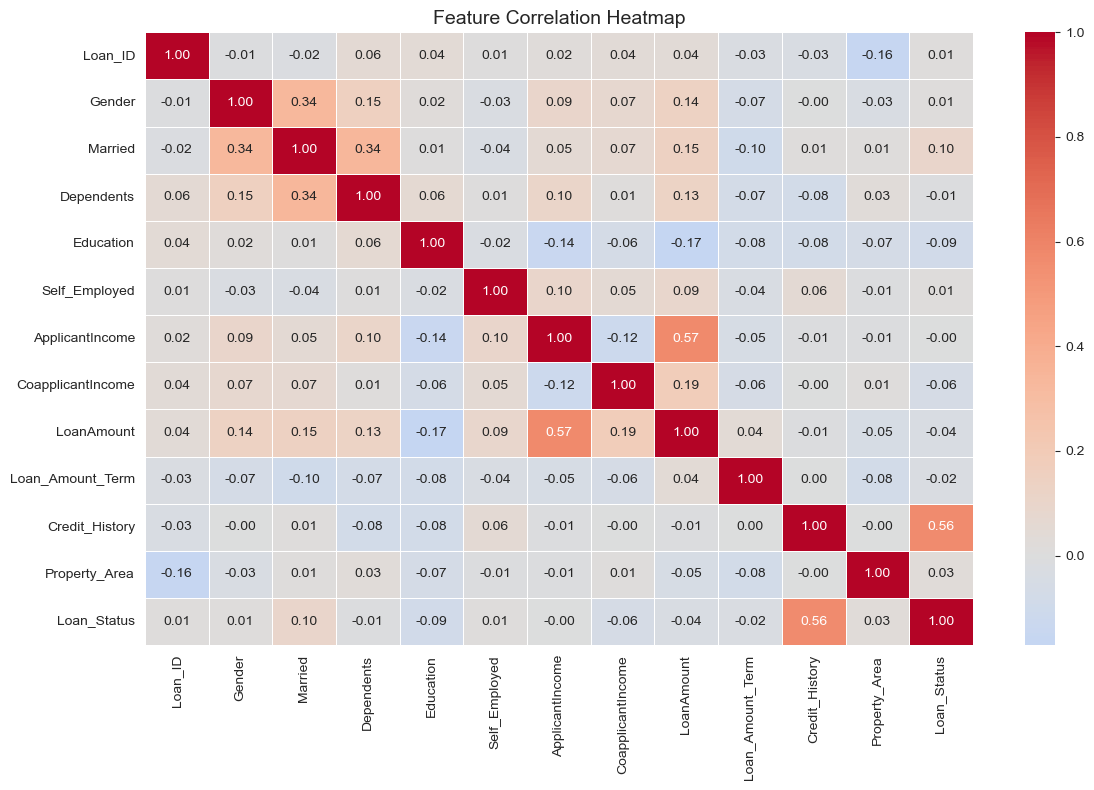

In [8]:
# Encode categoricals temporarily for correlation
df_corr = df.copy()
le = LabelEncoder()
cat_cols = df_corr.select_dtypes(include='object').columns
for col in cat_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

Credit history shows the strongest correlation with loan status — consistent with real-world lending, where credit score is the primary factor in approval decisions. Loan amount and applicant income show moderate positive correlation, as higher earners tend to request larger loans.

In [9]:
# Preprocessing phase

df_model = df.copy()

# Drop Loan_ID - not a predictive feature
df_model = df_model.drop(columns=['Loan_ID'])

# Fill missing values
df_model['Gender'].fillna(df_model['Gender'].mode()[0], inplace=True)
df_model['Married'].fillna(df_model['Married'].mode()[0], inplace=True)
df_model['Dependents'].fillna(df_model['Dependents'].mode()[0], inplace=True)
df_model['Self_Employed'].fillna(df_model['Self_Employed'].mode()[0], inplace=True)
df_model['LoanAmount'].fillna(df_model['LoanAmount'].median(), inplace=True)
df_model['Loan_Amount_Term'].fillna(df_model['Loan_Amount_Term'].mode()[0], inplace=True)
df_model['Credit_History'].fillna(df_model['Credit_History'].mode()[0], inplace=True)

print("Missing values after imputation:\n", df_model.isnull().sum())

Missing values after imputation:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [10]:
# Log transform skewed features
df_model['LoanAmount_Log'] = np.log1p(df_model['LoanAmount'])
df_model['ApplicantIncome_Log'] = np.log1p(df_model['ApplicantIncome'])
df_model['TotalIncome'] = df_model['ApplicantIncome'] + df_model['CoapplicantIncome']
df_model['TotalIncome_Log'] = np.log1p(df_model['TotalIncome'])

# Drop original skewed columns
df_model = df_model.drop(columns=['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome', 'TotalIncome'])

# Encode categorical variables
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Loan_Status']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Encode target variable
df_model['Loan_Status'] = le.fit_transform(df_model['Loan_Status'])
# Y (Approved) = 1, N (Denied) = 0

# Define features and target
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nFeatures used: {X.columns.tolist()}")

Training set: 491 samples
Test set:     123 samples

Features used: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'LoanAmount_Log', 'ApplicantIncome_Log', 'TotalIncome_Log']


In [11]:
# Modeling Phase

# Helper evaluation function
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

    print(f"\n{'='*55}")
    print(f"Model: {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Default (N)', 'Approved (Y)']))
    print(f"ROC-AUC Score:          {roc_auc_score(y_test, y_prob):.4f}")
    print(f"Cross-Val ROC-AUC:      {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Default', 'Approved'],
                yticklabels=['Default', 'Approved'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    return model, roc_auc_score(y_test, y_prob)


Model: Logistic Regression
              precision    recall  f1-score   support

 Default (N)       0.95      0.55      0.70        38
Approved (Y)       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

ROC-AUC Score:          0.8099
Cross-Val ROC-AUC:      0.7095 (+/- 0.0563)


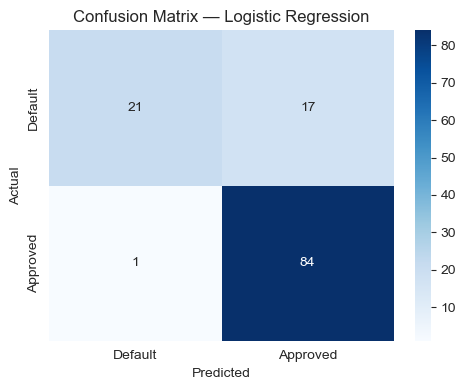


Model: Random Forest
              precision    recall  f1-score   support

 Default (N)       0.71      0.66      0.68        38
Approved (Y)       0.85      0.88      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.77      0.78       123
weighted avg       0.81      0.81      0.81       123

ROC-AUC Score:          0.8192
Cross-Val ROC-AUC:      0.7664 (+/- 0.0425)


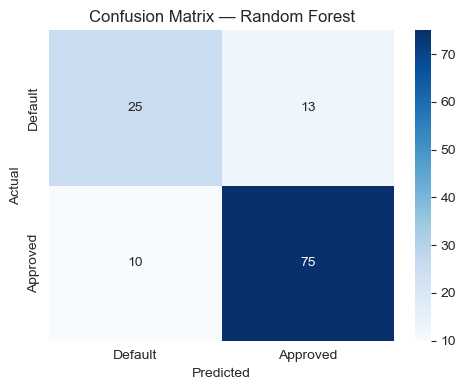

In [12]:
# Running both models (Logistic Regression & Random Forest)
lr, lr_roc = evaluate_model("Logistic Regression",
                             LogisticRegression(random_state=42),
                             X_train, X_test, y_train, y_test)

rf, rf_roc = evaluate_model("Random Forest",
                             RandomForestClassifier(n_estimators=100, random_state=42),
                             X_train, X_test, y_train, y_test)

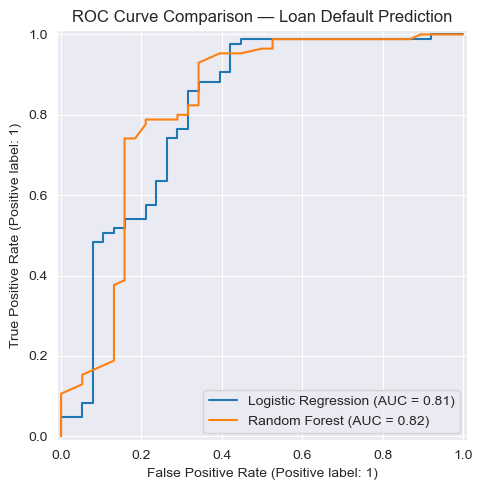

In [13]:
# ROC Curve Comparison for both models
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')
ax.set_title('ROC Curve Comparison — Loan Default Prediction')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150)
plt.show()

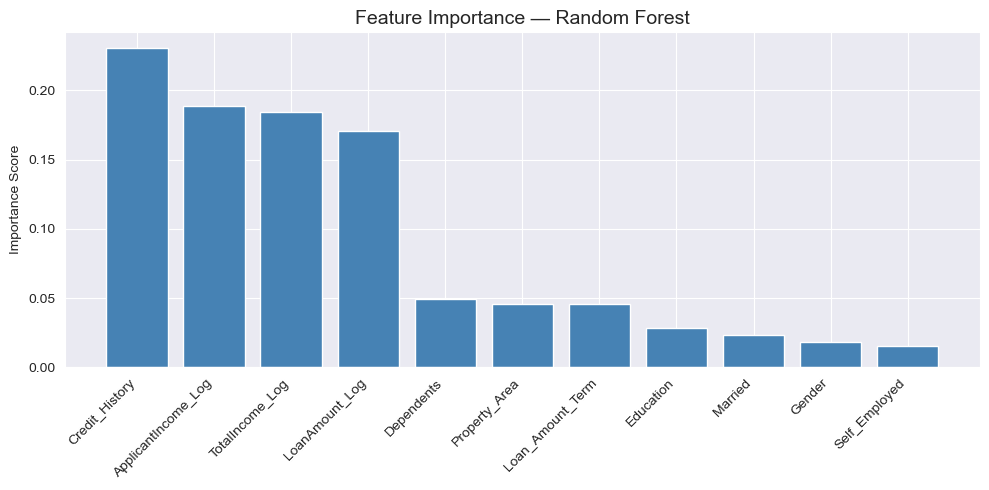

In [14]:
# Visualization showcasing Feature Importance (Random Forest)
feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(importances)), importances[indices], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.set_title('Feature Importance — Random Forest', fontsize=14)
ax.set_ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

Credit history is by far the most important feature, followed by total income and loan amount. This aligns with real-world lending practice — a borrower's repayment history is the strongest signal of future behavior.

## Results Summary

| Model               | ROC-AUC | Default Recall | Default Precision | CV ROC-AUC          |
|---------------------|---------|----------------|-------------------|---------------------|
| Logistic Regression | 0.81    | 0.55           | 0.95              | 0.71 (+/- 0.056)    |
| Random Forest       | 0.82    | 0.66           | 0.71              | 0.77 (+/- 0.043)    |

## Business Interpretation

**A clear and meaningful tradeoff emerged between the two models:**

Logistic Regression achieved very high default precision (0.95) — meaning when it predicted a borrower would default, it was correct 95% of the time. However, its default recall of just 0.55 means it missed 45% of actual defaulters, approving borrowers who would go on to default. In a real lending environment, those missed defaults translate directly to financial losses on the institution's balance sheet.

Random Forest offered a more balanced tradeoff — catching more actual defaulters (recall 0.66 vs 0.55) while maintaining reasonable precision (0.71). It also generalized better, with a stronger cross-validation ROC-AUC of 0.77 compared to Logistic Regression's 0.71, and a lower variance between folds (+/- 0.043 vs +/- 0.056) — suggesting it is more stable and reliable on unseen data.

**The cross-validation gap is worth noting:**
Logistic Regression's test ROC-AUC (0.81) is noticeably higher than its cross-val score (0.71), suggesting it may be somewhat optimistic on this particular test split. Random Forest's scores are more consistent (0.82 test vs 0.77 CV), making it the more trustworthy model overall.

**Model recommendation:**
Random Forest is the stronger choice for a production lending environment. Its better recall means fewer defaulters slip through, its cross-validation performance is more consistent, and its feature importance output provides interpretability that risk and compliance teams require. Credit history emerged as the dominant predictive feature — consistent with how real-world lending institutions weight repayment history above all other factors.

**The cost of errors in lending:**
- A false negative (approving a borrower who defaults) = direct financial loss
- A false positive (denying a creditworthy borrower) = lost revenue and potential fair lending scrutiny

The optimal classification threshold should be tuned based on the lender's risk appetite — a risk-averse institution would lower the threshold to catch more defaulters at the cost of denying more legitimate applicants.

**Limitations:**
- Dataset is small (614 rows) — both models would benefit significantly from more training data to improve generalization
- Missing values were imputed using mode/median, which may introduce bias in a real-world pipeline
- A production model would incorporate bureau credit scores, debt-to-income ratios, and more granular financial history
- Regulatory compliance in lending (Fair Lending Act) requires model explainability — SHAP values would be a critical next step

**Next Steps:**
- Implement SHAP values to explain individual predictions — essential for regulatory compliance in lending
- Tune the classification threshold to optimize the precision-recall tradeoff based on the institution's risk tolerance
- Try XGBoost or Gradient Boosting for potentially stronger performance
- Collect more training data to close the gap between test and cross-validation scores